ARTI308 - Machine Learning

# Lab 4: Data Quality Assessment & Preprocessing


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## 1. Identify data quality issues in the dataset

In [52]:
df.info()
df.isna().sum()
df.duplicated().sum()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   user_id                  420 non-null    int64   
 1   age_group                420 non-null    str     
 2   role                     420 non-null    category
 3   primary_platform         420 non-null    str     
 4   learning_device          420 non-null    str     
 5   hours_per_week           420 non-null    int64   
 6   learning_purpose         420 non-null    str     
 7   content_type_preference  420 non-null    str     
 8   completion_rate_percent  420 non-null    int64   
 9   satisfaction_score       420 non-null    int64   
dtypes: category(1), int64(4), str(5)
memory usage: 30.3 KB


,user_id,age_group,role,primary_platform,learning_device,hours_per_week,learning_purpose,content_type_preference,completion_rate_percent,satisfaction_score
count,420.000000,420,420,420,420,420.000000,420,420,420.000000,420.000000
unique,NaN,5,4,6,4,NaN,4,3,NaN,NaN
top,NaN,35-44,Student,Skillshare,Mobile,NaN,Career Growth,Text,NaN,NaN
freq,NaN,98,132,79,111,NaN,116,148,NaN,NaN
mean,210.500000,NaN,NaN,NaN,NaN,10.476190,NaN,NaN,53.935714,5.228571
std,121.387808,NaN,NaN,NaN,NaN,5.708253,NaN,NaN,26.638357,2.814918
min,1.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,10.000000,1.000000
25%,105.750000,NaN,NaN,NaN,NaN,5.750000,NaN,NaN,30.000000,3.000000
50%,210.500000,NaN,NaN,NaN,NaN,11.000000,NaN,NaN,54.000000,5.000000
75%,315.250000,NaN,NaN,NaN,NaN,15.000000,NaN,NaN,77.250000,8.000000


## 2. Load Dataset

In [2]:
# pd.set_option("display.max_columns",None)
df = pd.read_csv("online_learning_platform_usage_dataset.csv")

In [3]:
df.head()

,user_id,age_group,role,primary_platform,learning_device,hours_per_week,learning_purpose,content_type_preference,completion_rate_percent,satisfaction_score
0,1,35-44,Working Professional,edX,Laptop,10,Career Growth,Text,34,5
1,2,45+,Other,edX,Mobile,12,Career Growth,Text,17,3
2,3,25-34,Freelancer,Skillshare,Desktop,2,Academic,Text,67,9
3,4,45+,Working Professional,Udemy,Mobile,3,Career Growth,Mixed,25,5
4,5,45+,Working Professional,Khan Academy,Mobile,10,Hobby,Video,81,5


## 2.1. Data Quality Assessment


In [8]:
df.dtypes

user_id                    int64
age_group                    str
role                         str
primary_platform             str
learning_device              str
hours_per_week             int64
learning_purpose             str
content_type_preference      str
completion_rate_percent    int64
satisfaction_score         int64
dtype: object

In [12]:
df['hours_per_week'] = pd.to_numeric(df['hours_per_week'])

In [14]:
df.dtypes

user_id                    int64
age_group                    str
role                         str
primary_platform             str
learning_device              str
hours_per_week             int64
learning_purpose             str
content_type_preference      str
completion_rate_percent    int64
satisfaction_score         int64
dtype: object

In [15]:
df['role'] = df['role'].astype('category')

In [16]:
df.dtypes

user_id                       int64
age_group                       str
role                       category
primary_platform                str
learning_device                 str
hours_per_week                int64
learning_purpose                str
content_type_preference         str
completion_rate_percent       int64
satisfaction_score            int64
dtype: object

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [17]:
df.isna()

,user_id,age_group,role,primary_platform,learning_device,hours_per_week,learning_purpose,content_type_preference,completion_rate_percent,satisfaction_score
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
415,False,False,False,False,False,False,False,False,False,False
416,False,False,False,False,False,False,False,False,False,False
417,False,False,False,False,False,False,False,False,False,False
418,False,False,False,False,False,False,False,False,False,False


In [18]:
df.isna().sum()

user_id                    0
age_group                  0
role                       0
primary_platform           0
learning_device            0
hours_per_week             0
learning_purpose           0
content_type_preference    0
completion_rate_percent    0
satisfaction_score         0
dtype: int64

### 3.2 Demonstration: Introduce Artificial Missing Values

In [54]:
df2 = df.copy()
df2.loc[0:5, 'hours_per_week'] = np.nan


In [20]:
df2.isna().sum()

user_id                      0
age_group                    0
role                         0
primary_platform             0
learning_device              0
hours_per_week               0
learning_purpose             0
content_type_preference      0
completion_rate_percent      0
satisfaction_score           0
Amount                     420
dtype: int64

In [21]:
df2.head(10)

,user_id,age_group,role,primary_platform,learning_device,hours_per_week,learning_purpose,content_type_preference,completion_rate_percent,satisfaction_score,Amount
0,1,35-44,Working Professional,edX,Laptop,10,Career Growth,Text,34,5,NaN
1,2,45+,Other,edX,Mobile,12,Career Growth,Text,17,3,NaN
2,3,25-34,Freelancer,Skillshare,Desktop,2,Academic,Text,67,9,NaN
3,4,45+,Working Professional,Udemy,Mobile,3,Career Growth,Mixed,25,5,NaN
4,5,45+,Working Professional,Khan Academy,Mobile,10,Hobby,Video,81,5,NaN
5,6,18-24,Freelancer,Khan Academy,Mobile,2,Hobby,Text,10,4,NaN
6,7,25-34,Working Professional,Skillshare,Tablet,13,Hobby,Video,14,4,NaN
7,8,25-34,Other,YouTube,Tablet,13,Hobby,Video,12,1,NaN
8,9,25-34,Student,Udemy,Laptop,18,Career Growth,Mixed,74,7,NaN
9,10,45+,Other,Skillshare,Laptop,3,Academic,Video,13,9,NaN


### Strategy 1: Remove Records


In [22]:
df_remove = df2.dropna()

In [23]:
print('df with NaN: ',df2.shape)
print('df without NaN: ',df_remove.shape)

df with NaN:  (420, 11)
df without NaN:  (0, 11)


In [24]:
df_remove.isna().sum()

user_id                    0
age_group                  0
role                       0
primary_platform           0
learning_device            0
hours_per_week             0
learning_purpose           0
content_type_preference    0
completion_rate_percent    0
satisfaction_score         0
Amount                     0
dtype: int64

### Strategy 2: Mean Imputation



In [29]:
df_mean = df2.copy()
df_mean['hours_per_week'] = df_mean['hours_per_week'].fillna(df_mean['hours_per_week'].mean())

In [31]:
df_mean.head(10)

,user_id,age_group,role,primary_platform,learning_device,hours_per_week,learning_purpose,content_type_preference,completion_rate_percent,satisfaction_score,Amount
0,1,35-44,Working Professional,edX,Laptop,10,Career Growth,Text,34,5,NaN
1,2,45+,Other,edX,Mobile,12,Career Growth,Text,17,3,NaN
2,3,25-34,Freelancer,Skillshare,Desktop,2,Academic,Text,67,9,NaN
3,4,45+,Working Professional,Udemy,Mobile,3,Career Growth,Mixed,25,5,NaN
4,5,45+,Working Professional,Khan Academy,Mobile,10,Hobby,Video,81,5,NaN
5,6,18-24,Freelancer,Khan Academy,Mobile,2,Hobby,Text,10,4,NaN
6,7,25-34,Working Professional,Skillshare,Tablet,13,Hobby,Video,14,4,NaN
7,8,25-34,Other,YouTube,Tablet,13,Hobby,Video,12,1,NaN
8,9,25-34,Student,Udemy,Laptop,18,Career Growth,Mixed,74,7,NaN
9,10,45+,Other,Skillshare,Laptop,3,Academic,Video,13,9,NaN


## 4. Handling Outliers


In [34]:
import matplotlib.pyplot as plt

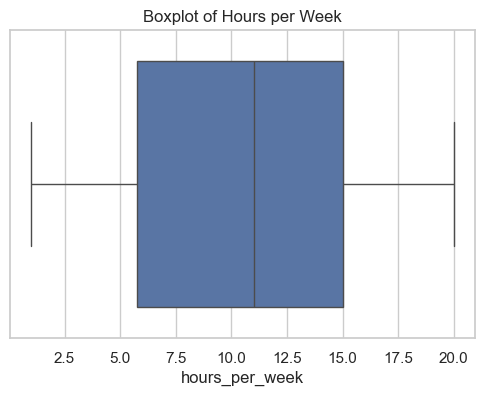

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['hours_per_week'])
plt.title('Boxplot of Hours per Week')
plt.show()

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

In [36]:
Q1 = df['hours_per_week'].quantile(0.25)
Q3 = df['hours_per_week'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['hours_per_week'] < lower) | (df['hours_per_week'] > upper)]
print("Number of outliers:", outliers.shape[0])
outliers.head()

Number of outliers: 0


,user_id,age_group,role,primary_platform,learning_device,hours_per_week,learning_purpose,content_type_preference,completion_rate_percent,satisfaction_score


I used the IQR method to detect outliers in the hours_per_week column. The result showed that there were no outliers according to the IQR rule. Therefore, no rows needed to be removed. This indicates that the weekly learning hours are within a reasonable range.

### Remove Outliers (no need in my case but i just put it)


In [38]:
df_no_outliers = df[(df['hours_per_week'] >= lower) & (df['hours_per_week'] <= upper)]

print("Original shape:", df.shape)
print("Without outliers:", df_no_outliers.shape)

Original shape: (420, 10)
Without outliers: (420, 10)


### Capping Outliers (Percentile Method)


In [39]:

lower_cap = df['hours_per_week'].quantile(0.05)
upper_cap = df['hours_per_week'].quantile(0.95)

df_capped = df.copy()
df_capped['hours_per_week'] = df_capped['hours_per_week'].clip(lower_cap, upper_cap)

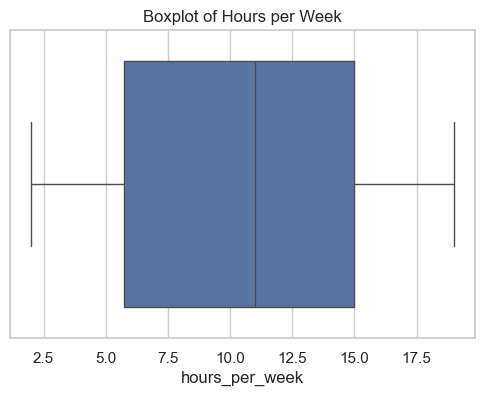

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['hours_per_week'])

plt.title('Boxplot of Hours per Week')
plt.show()

## 5. Data Transformation – Normalization

### Min-Max Normalization


In [43]:
df[['hours_per_week', 'completion_rate_percent']].head()

,hours_per_week,completion_rate_percent
0,10,34
1,12,17
2,2,67
3,3,25
4,10,81


In [44]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['hours_per_week', 'completion_rate_percent', 'satisfaction_score']].copy()

df_scaled[['hours_per_week', 'completion_rate_percent', 'satisfaction_score']] = scaler.fit_transform(
    df_scaled[['hours_per_week', 'completion_rate_percent', 'satisfaction_score']]
)

df_scaled.head()

,hours_per_week,completion_rate_percent,satisfaction_score
0,0.473684,0.266667,0.444444
1,0.578947,0.077778,0.222222
2,0.052632,0.633333,0.888889
3,0.105263,0.166667,0.444444
4,0.473684,0.788889,0.444444


### Z-Score Normalization


In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['hours_per_week', 'completion_rate_percent', 'satisfaction_score']].copy()

df_standardized[['hours_per_week', 'completion_rate_percent', 'satisfaction_score']] = scaler.fit_transform(
    df_standardized[['hours_per_week', 'completion_rate_percent', 'satisfaction_score']]
)

df_standardized.head()

,hours_per_week,completion_rate_percent,satisfaction_score
0,-0.083521,-0.749276,-0.081297
1,0.267267,-1.388215,-0.792644
2,-1.486672,0.491016,1.341398
3,-1.311278,-1.087538,-0.081297
4,-0.083521,1.017201,-0.081297


## Check Correlation Before Applying PCA



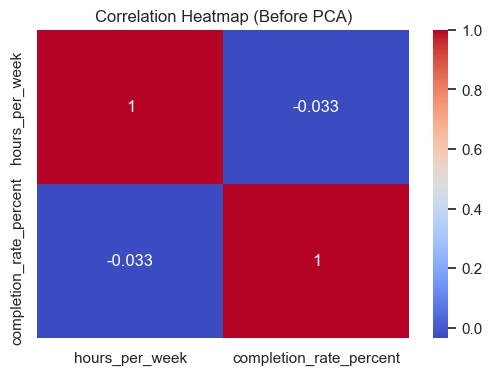

In [48]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['hours_per_week', 'completion_rate_percent']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The correlation between hours_per_week and completion_rate_percent is very weak (-0.033). This means the two features do not strongly overlap in information. Therefore, PCA is not necessary for this dataset, although it can still be applied for demonstration purposes.

## 6. Data Reduction – Principal Component Analysis (PCA)



In [49]:
from sklearn.decomposition import PCA

X = df_standardized[['hours_per_week', 'completion_rate_percent']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.5166619 0.4833381]


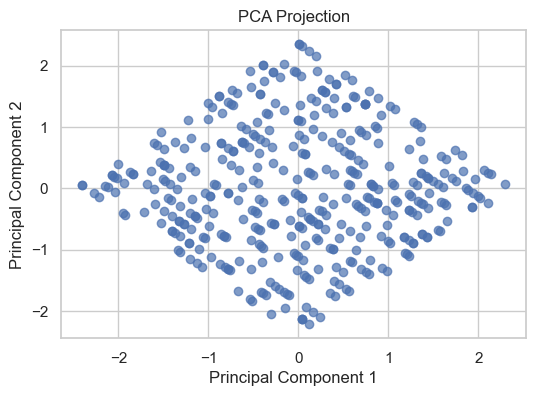

In [50]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1], alpha=0.7)
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA only if the numerical features show a correlation.


End of lab 4.